# H2 supporting study: the classifier head

mxbai-v1 reduces out-of-distribution maximum |d| by 0.064 under the invariance
term, the smallest reduction of the six models, and it is also the one model
whose classifier head uses GELU where the other five use tanh. Each encoder is
frozen and its first-token representation cached, then every head is fitted to
that representation on the same loss, the same budget and three seeds, so two
arms differ only in the head.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

from fsr.head_probe.heads import GELU, LINEAR, TANH, WIDE_LINEAR
from fsr.head_probe.results import (
    activation_contrast,
    arm_table,
    available,
    capacity_contrast,
    contrast_verdict,
    frontier_frame,
    load_frontier,
    mrr_table,
    weights_of,
)
from fsr.models.registry import by_slug

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.45,
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.9,
    }
)

SAFE = sns.color_palette("colorblind")
FOCUS = {GELU: SAFE[0], TANH: SAFE[1]}
CONTEXT = "0.62"
MUTED_FILL = "0.88"
MUTED_EDGE = "0.6"
RULE = "0.35"
ERROR = "0.45"

ARMS = (LINEAR, WIDE_LINEAR, GELU, TANH)
STYLE = {
    LINEAR: {"color": CONTEXT, "ls": "--", "lw": 1.0, "marker": "", "ms": 0},
    WIDE_LINEAR: {"color": CONTEXT, "ls": ":", "lw": 1.2, "marker": "", "ms": 0},
    GELU: {"color": FOCUS[GELU], "ls": "-", "lw": 1.8, "marker": "o", "ms": 5},
    TANH: {"color": FOCUS[TANH], "ls": "-", "lw": 1.8, "marker": "s", "ms": 5},
}

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "nq"
FIG_DIR = ROOT / "notebooks" / "h2" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WEIGHT_LABEL = "invariance weight ($\\lambda$)"
SCORE_LABEL = "dev max |d|"


def save(fig, name):
    """Write the figure as a vector PDF for the thesis and a PNG to read."""
    fig.tight_layout()
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")


def leader_colours(values, resolved):
    """Return the fill and edge colour of each point, by which arm leads."""
    fill, edge = [], []
    for value, clear in zip(values, resolved, strict=True):
        colour = FOCUS[TANH] if value < 0 else FOCUS[GELU]
        fill.append(colour if clear else MUTED_FILL)
        edge.append(colour if clear else MUTED_EDGE)
    return fill, edge


SLUGS = available(DATA_ROOT)
LABELS = [by_slug(slug).label for slug in SLUGS]
WEIGHTS = weights_of(DATA_ROOT, SLUGS[0])
TICKS = [f"{weight:g}" for weight in WEIGHTS]
X = np.arange(len(WEIGHTS))

for slug in SLUGS:
    meta = load_frontier(DATA_ROOT, slug)
    print(
        f"{by_slug(slug).label:<10} {len(meta['points'])} fits, "
        f"{len(meta['failures'])} failures, "
        f"{meta['n_fit_records']} fit records, "
        f"{meta['n_eval_records']} {meta['eval_split']} records"
    )

mxbai-v1   75 fits, 0 failures, 6131 fit records, 758 dev records
jina-v2    75 fits, 0 failures, 6131 fit records, 758 dev records


## The arms

In [2]:
arm_table(DATA_ROOT, SLUGS[0], ARMS)

,parameters,affine,bounded
head,,,
linear,769,True,False
wide_linear,591361,True,False
gelu,591361,False,False
tanh,591361,False,True


`gelu` is the head mxbai-v1 carries and `tanh` the head the other five carry, and
the two hold 591,361 parameters at equal depth, so the contrast between them
isolates the activation. `linear` and `wide_linear` are both affine and differ
only in width, so the contrast between those two isolates capacity.

## Frontier

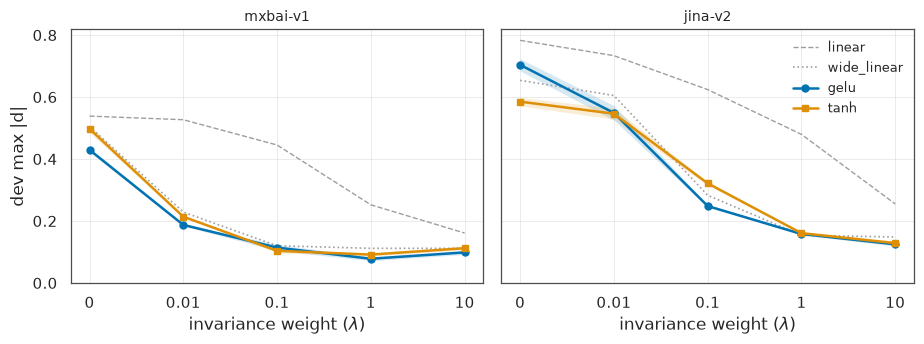

In [3]:
fig, axs = plt.subplots(1, len(SLUGS), figsize=(9.4, 3.6), sharey=True)
for ax, slug, label in zip(axs, SLUGS, LABELS, strict=True):
    frame = frontier_frame(DATA_ROOT, slug, ARMS)
    for head in ARMS:
        row = frame.loc[head]
        mean = row["max_abs_d"].to_numpy()
        ax.plot(X, mean, label=head, zorder=3, **STYLE[head])
        if head in FOCUS:
            spread = row["max_abs_d_sd"].to_numpy()
            ax.fill_between(
                X,
                mean - spread,
                mean + spread,
                color=FOCUS[head],
                alpha=0.16,
                lw=0,
                zorder=2,
            )
    ax.set_title(label, fontsize=10)
    ax.set_xticks(X)
    ax.set_xticklabels(TICKS)
    ax.set_xlabel(WEIGHT_LABEL)

axs[0].set_ylabel(SCORE_LABEL)
axs[0].set_ylim(0, None)
axs[-1].legend(frameon=False, fontsize=9, loc="upper right")
save(fig, "head_probe_frontier")

## Activation: GELU against tanh

In [4]:
contrast = activation_contrast(DATA_ROOT, SLUGS)
contrast.round(4)

gelu    tanh  tanh_minus_gelu    band  resolved
model    weight                                                   
mxbai-v1 0.00    0.4295  0.4976           0.0681  0.0200      True
         0.01    0.1874  0.2139           0.0265  0.0053      True
         0.10    0.1142  0.1038          -0.0104  0.0167     False
         1.00    0.0781  0.0916           0.0134  0.0112      True
         10.00   0.0986  0.1122           0.0136  0.0125      True
jina-v2  0.00    0.7040  0.5852          -0.1188  0.0337      True
         0.01    0.5488  0.5463          -0.0026  0.0416     False
         0.10    0.2483  0.3215           0.0732  0.0099      True
         1.00    0.1580  0.1608           0.0027  0.0053     False
         10.00   0.1248  0.1286           0.0038  0.0131     False

6/10 cells clear the seed band: 1 favour tanh, 5 favour GELU


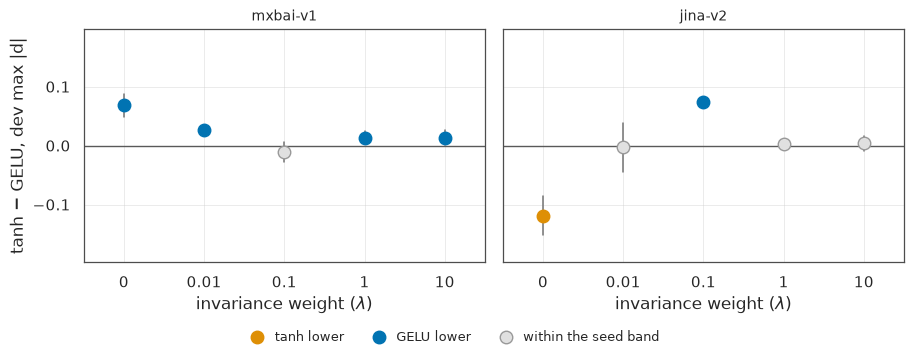

In [5]:
fig, axs = plt.subplots(1, len(SLUGS), figsize=(9.4, 3.4), sharey=True)
for ax, label in zip(axs, LABELS, strict=True):
    frame = contrast.loc[label]
    point = frame["tanh_minus_gelu"].to_numpy()
    band = frame["band"].to_numpy()
    fill, edge = leader_colours(point, frame["resolved"])

    ax.axhline(0, color=RULE, lw=1, zorder=1)
    for x, value, width, f, e in zip(X, point, band, fill, edge, strict=True):
        ax.plot([x, x], [value - width, value + width], color=ERROR, lw=1.1, zorder=2)
        ax.plot([x], [value], marker="o", ms=9, mfc=f, mec=e, mew=1.0, zorder=3)

    ax.set_title(label, fontsize=10)
    ax.set_xticks(X)
    ax.set_xticklabels(TICKS)
    ax.set_xlim(-0.5, len(X) - 0.5)
    ax.set_xlabel(WEIGHT_LABEL)

limit = float((contrast["tanh_minus_gelu"].abs() + contrast["band"]).max()) * 1.3
axs[0].set_ylim(-limit, limit)
axs[0].set_ylabel("tanh $-$ GELU, " + SCORE_LABEL)

keys = [
    (FOCUS[TANH], FOCUS[TANH], "tanh lower"),
    (FOCUS[GELU], FOCUS[GELU], "GELU lower"),
    (MUTED_FILL, MUTED_EDGE, "within the seed band"),
]
fig.legend(
    handles=[
        Line2D([], [], ls="", marker="o", ms=9, mfc=f, mec=e, mew=1.0, label=text)
        for f, e, text in keys
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=len(keys),
    frameon=False,
    fontsize=9,
    handletextpad=0.4,
    columnspacing=1.8,
)
save(fig, "head_probe_activation")

verdict = contrast_verdict(contrast)
print(
    f"{verdict['resolved']}/{verdict['cells']} cells clear the seed band: "
    f"{verdict['tanh_lower']} favour tanh, {verdict['gelu_lower']} favour GELU"
)

Six of the ten cells clear the seed band, five favouring GELU and one tanh, and
at $\lambda = 0$ the sign reverses between the two representations. The bounded
activation therefore does not reduce format sensitivity on either, so the head
activation does not explain why mxbai-v1 responds least. The probe fits a new
head to a frozen encoder, so it bounds what a head can reach and not what LoRA
fine-tuning reached.

## Capacity: one layer against two

In [6]:
capacity_contrast(DATA_ROOT, SLUGS).round(4)

linear  wide_linear  wide_minus_linear    band  resolved
model    weight                                                          
mxbai-v1 0.00    0.5385       0.5050            -0.0335  0.0231      True
         0.01    0.5269       0.2287            -0.2982  0.0246      True
         0.10    0.4453       0.1201            -0.3252  0.0302      True
         1.00    0.2522       0.1118            -0.1404  0.0413      True
         10.00   0.1612       0.1118            -0.0494  0.0341      True
jina-v2  0.00    0.7830       0.6539            -0.1291  0.0313      True
         0.01    0.7337       0.6051            -0.1286  0.0169      True
         0.10    0.6241       0.2829            -0.3411  0.0195      True
         1.00    0.4795       0.1541            -0.3254  0.0164      True
         10.00   0.2551       0.1483            -0.1067  0.0186      True

The two-layer head is below the one-layer head at every weight on both models, on
ten of ten non-overlapping bands and by 0.034 to 0.341, although both arms are
affine and differ only in width. Width therefore changes what a head reaches
where the activation does not. No head in the roster is one layer, so `linear`
serves as the floor of the probe and not as a model of mxbai-v1.

## Ranking quality

In [7]:
mrr = mrr_table(DATA_ROOT, SLUGS, ARMS)
print(f"mean MRR spans {mrr.to_numpy().min():.4f} to {mrr.to_numpy().max():.4f}")
mrr.round(4)

mean MRR spans 0.9323 to 0.9615


weight                 0.00    0.01    0.10    1.00    10.00
model    head                                               
mxbai-v1 linear       0.9323  0.9325  0.9332  0.9355  0.9385
         wide_linear  0.9465  0.9470  0.9482  0.9492  0.9459
         gelu         0.9474  0.9475  0.9487  0.9506  0.9488
         tanh         0.9463  0.9465  0.9479  0.9492  0.9477
jina-v2  linear       0.9492  0.9493  0.9494  0.9500  0.9530
         wide_linear  0.9554  0.9558  0.9580  0.9602  0.9580
         gelu         0.9572  0.9578  0.9604  0.9614  0.9591
         tanh         0.9536  0.9538  0.9576  0.9615  0.9596

Mean MRR spans 0.932 to 0.962 over every arm, weight and seed, and no single arm
varies by more than 0.008 across the whole weight sweep. No arm therefore reaches
its score axis by giving up ranking quality.